In [16]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
from torch.utils.data import Dataset
import torchvision.models as models
from torchvision import transforms
from torch.utils.data import DataLoader

from tqdm import tqdm
import time
from sklearn.metrics import mean_absolute_error, mean_squared_error
from PIL import Image
import json

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [17]:
df = pd.read_parquet("Data/dipser_transformed_data.parquet", engine="pyarrow")
df["time_sec"] = df["time"].astype(str).str[:8]
df['subject_id'] = df['group'] + "_" + df['subject'] 
df.head()

,group,time,subject,experiment,image_path,metadata,labeler_02 emotion,labeler_02 attention,labeler_01 attention,labeler_04 attention,...,samsung_rotation_vector_std_value3,opt3007_light_mean,opt3007_light_std,samsung_hr_none_wakeup_sensor_value,gender_name,age,race,attention,time_sec,subject_id
0,group01,10:59:49.000776,subject_01,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,9.0,3.0,2.0,3.0,...,0.000083,69.0,0.0,94.0,male,27.0,white,2.75,10:59:49,group01_subject_01
1,group01,10:59:49.147013,subject_01,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,NaN,NaN,NaN,NaN,...,0.000083,69.0,0.0,94.0,male,27.0,white,2.75,10:59:49,group01_subject_01
2,group01,10:59:49.252899,subject_01,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,NaN,NaN,NaN,NaN,...,0.000083,69.0,0.0,94.0,male,27.0,white,2.75,10:59:49,group01_subject_01
3,group01,10:59:49.343618,subject_01,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,NaN,NaN,NaN,NaN,...,0.000083,69.0,0.0,94.0,male,27.0,white,2.75,10:59:49,group01_subject_01
4,group01,10:59:49.504931,subject_01,experiment02,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,/gpfs/work5/0/prjs2039/DIPSER/group01/experime...,NaN,NaN,NaN,NaN,...,0.000083,69.0,0.0,94.0,male,27.0,white,2.75,10:59:49,group01_subject_01


In [18]:
df.columns

Index(['group', 'time', 'subject', 'experiment', 'image_path', 'metadata',
       'labeler_02 emotion', 'labeler_02 attention', 'labeler_01 attention',
       'labeler_04 attention', 'labeler_04 emotion', 'labeler_03 emotion',
       'labeler_03 attention', 'labeler_01 emotion', 'self_labeling emotion',
       'self_labeling attention', 'labeler_02 emotionfilled',
       'labeler_02 attentionfilled', 'labeler_01 attentionfilled',
       'labeler_04 attentionfilled', 'labeler_04 emotionfilled',
       'labeler_03 emotionfilled', 'labeler_03 attentionfilled',
       'labeler_01 emotionfilled', 'self_labeling emotionfilled',
       'self_labeling attentionfilled', 'labeler_05 emotion',
       'labeler_05 attention', 'labeler_05 emotionfilled',
       'labeler_05 attentionfilled', 'lsm6dso_gyroscope_mean_x',
       'lsm6dso_gyroscope_std_x', 'lsm6dso_gyroscope_mean_y',
       'lsm6dso_gyroscope_std_y', 'lsm6dso_gyroscope_mean_z',
       'lsm6dso_gyroscope_std_z', 'lsm6dso_gyroscope_mean_ma

In [19]:
df[['attention', 'image_path']].isna().sum()

attention     0
image_path    0
dtype: int64

In [20]:
df_sec = (
    df.sort_values("time")
      .groupby(["subject_id", "time_sec"])
      .first()
      .reset_index()
)

In [21]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [22]:
class DipserImageDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row["image_path"]).convert("RGB")

        if self.transform:
            img = self.transform(img)

        label = torch.tensor(row["attention"], dtype=torch.float32)

        return img, label, idx

### Train Test Split

In [23]:
from sklearn.model_selection import train_test_split

subject_df = df_sec[['subject_id', 'gender_name']].drop_duplicates()

train_sub, test_sub = train_test_split(
    subject_df,
    test_size=0.2,
    stratify=subject_df['gender_name'],
    random_state=42
)

train_subjects = train_sub['subject_id']
test_subjects = test_sub['subject_id']

train_df = df_sec[df_sec["subject_id"].isin(train_subjects)]
test_df  = df_sec[df_sec["subject_id"].isin(test_subjects)]

In [24]:
train_dataset = DipserImageDataset(train_df, transform)
test_dataset  = DipserImageDataset(test_df, transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,         
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

In [25]:
class AttentionCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = models.resnet18(pretrained=True)

        # Replace final layer
        self.backbone.fc = nn.Sequential(
            nn.Linear(self.backbone.fc.in_features, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.backbone(x).squeeze(1)

In [36]:
criterion = nn.MSELoss()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AttentionCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

def train_one_epoch(model, loader):
    model.train()

    total_loss = 0
    preds_all = []
    labels_all = []

    pbar = tqdm(loader, desc="Training", leave=False)

    for imgs, labels, _ in pbar:
        imgs, labels = imgs.to(device), labels.to(device)

        preds = model(imgs)
        loss = criterion(preds, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds_all.extend(preds.detach().cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    # compute metrics
    train_mae = mean_absolute_error(labels_all, preds_all)
    train_rmse = np.sqrt(mean_squared_error(labels_all, preds_all))

    return total_loss / len(loader), train_mae, train_rmse

/home/cfragkiadakis/.local/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/cfragkiadakis/.local/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [27]:
def evaluate(model, loader):
    model.eval()

    preds_all = []
    labels_all = []
    inference_times = []

    pbar = tqdm(loader, desc="Evaluating", leave=False)

    with torch.no_grad():
        for imgs, labels, _ in pbar:
            imgs = imgs.to(device)

            start = time.time()
            preds = model(imgs)
            torch.cuda.synchronize()
            end = time.time()

            inference_times.append(end - start)

            preds = preds.cpu().numpy()

            preds_all.extend(preds)
            labels_all.extend(labels.numpy())

    mae = mean_absolute_error(labels_all, preds_all)
    rmse = np.sqrt(mean_squared_error(labels_all, preds_all))

    return mae, rmse, np.mean(inference_times), np.std(inference_times)

In [28]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = float("inf")
        self.counter = 0
        self.best_model = None

    def step(self, metric, model):
        if metric < self.best_score - self.min_delta:
            self.best_score = metric
            self.counter = 0
            self.best_model = model.state_dict()
            torch.save(early_stopping.best_model, "cnn_baseline_best.pt")  # save best model
            return False  # continue
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True  # stop
            return False

In [ ]:
early_stopping = EarlyStopping(patience=5)
NUM_EPOCHS = 50

train_losses = []
train_mae_list, train_rmse_list, val_mae_list, val_rmse_list = [], [], [], []
best_rmse = None
best_latency = None

for epoch in range(NUM_EPOCHS):
    train_loss, train_mae, train_rmse = train_one_epoch(model, train_loader)
    val_mae, val_rmse, avg_time, std_time = evaluate(model, test_loader)

    train_losses.append(train_loss)
    train_mae_list.append(train_mae)
    train_rmse_list.append(train_rmse)

    val_mae_list.append(val_mae)
    val_rmse_list.append(val_rmse)

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train MAE: {train_mae:.4f} | Train RMSE: {train_rmse:.4f}")
    print(f"Val MAE: {val_mae:.4f} | Val RMSE: {val_rmse:.4f}")

    if val_mae < early_stopping.best_score:
        best_rmse = val_rmse
        best_latency = avg_time

    stop = early_stopping.step(val_mae, model)

    if stop:
        print("Early stopping triggered")
        break

# load best model
model.load_state_dict(early_stopping.best_model)

best_mae = early_stopping.best_score

results = {
    "mae": best_mae,
    "rmse": best_rmse,
    "latency_per_batch": best_latency,
    "latency_per_sample_ms": (best_latency / train_loader.batch_size) * 1000,
    "epochs_trained": len(train_losses)
}

with open("cnn_results.json", "w") as f:
    json.dump(results, f, indent=4)

Training:   0%|          | 0/724 [00:00<?, ?it/s]

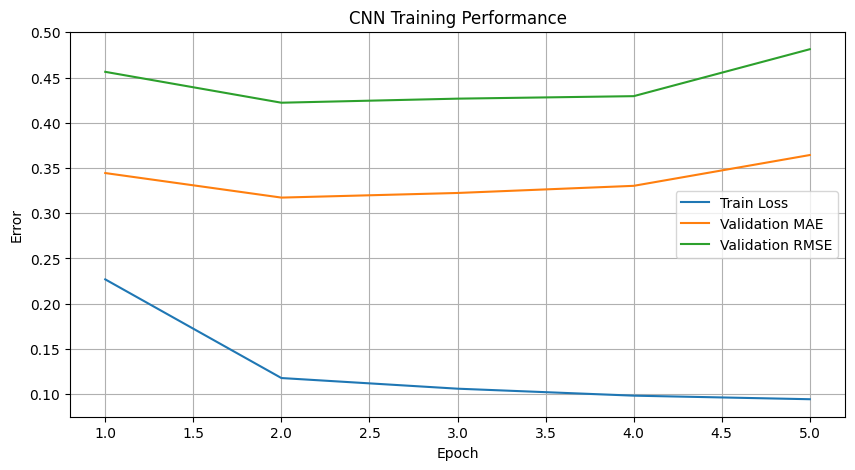

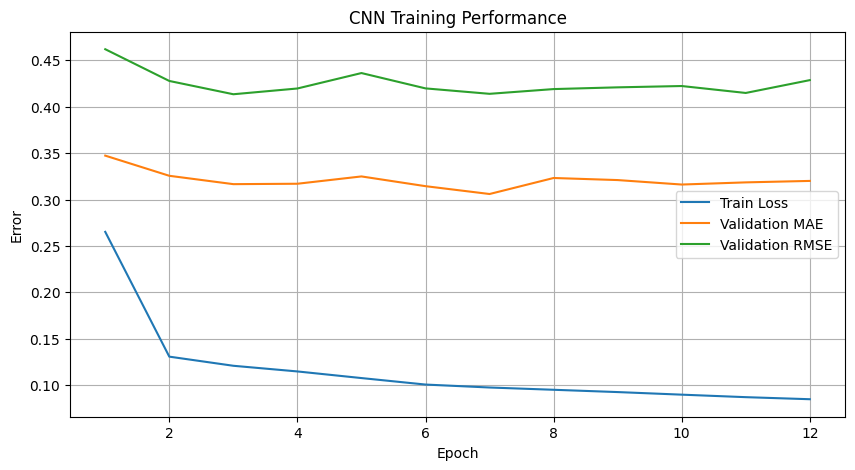

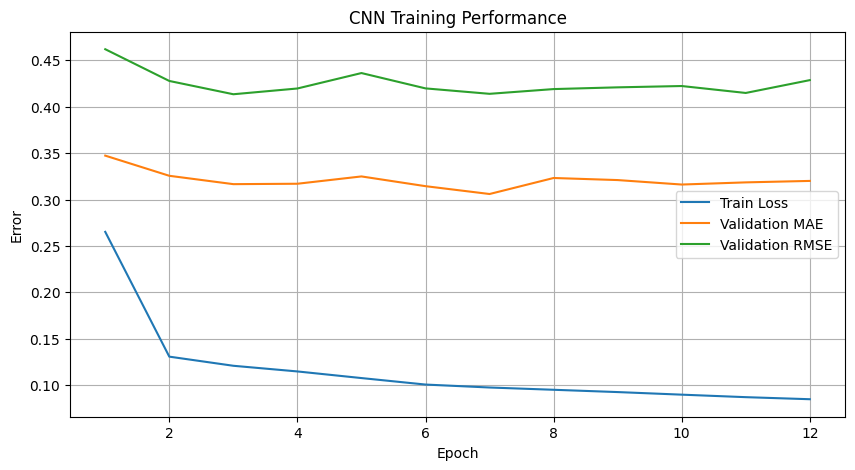

In [33]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_mae_list) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# --- RMSE plot ---
ax[0].plot(epochs, train_rmse_list, label="Train RMSE")
ax[0].plot(epochs, val_rmse_list, label="Validation RMSE")
ax[0].set_title("RMSE: Training vs Validation")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("RMSE")
ax[0].legend()
ax[0].grid()

# --- MAE plot ---
ax[1].plot(epochs, train_mae_list, label="Train MAE")
ax[1].plot(epochs, val_mae_list, label="Validation MAE")
ax[1].set_title("MAE: Training vs Validation")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("MAE")
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.savefig("cnn_training_curves.png", dpi=300, bbox_inches="tight")
plt.show()

In [34]:
batch_size = train_loader.batch_size
latency_per_sample = avg_time / batch_size

print(f"Latency per sample: {latency_per_sample*1000:.2f} ms")

Latency per sample: 0.06 ms


In [35]:
def evaluate_fairness(model, df, loader):
    model.eval()

    results = []

    with torch.no_grad():
        for imgs, labels, idx in loader:
            imgs = imgs.to(device)
            preds = model(imgs).cpu().numpy()

            for i in range(len(preds)):
                results.append({
                    "pred": preds[i],
                    "true": labels[i].item(),
                    "gender": df.iloc[idx[i]]["gender_name"]
                })

    res_df = pd.DataFrame(results)

    group_mae = res_df.groupby("gender").apply(
        lambda x: np.mean(np.abs(x["true"] - x["pred"]))
    )

    worst_group = group_mae.max()
    best_group = group_mae.min()
    gap = worst_group - best_group

    return group_mae, worst_group, gap